In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Configuration
# -----------------------------
DATA_ROOT = r"C:\Users\gb630\OneDrive\USD AAI\USD AAI\AAI-590 CAPSTONE\FINAL PROJECT\Data"
PARQUET_PATH = f"{DATA_ROOT}\geolife.parquet"
OUTPUT_DIR = "eda_figures"
MAX_FILES = 300             # Increase for full EDA
MAX_POINTS_PER_FILE = 5000  # Limit long trajectories for speed

os.makedirs(OUTPUT_DIR, exist_ok=True)


In [2]:
def load_geolife_plt(file_path):
    """
    Loads a GeoLife .plt trajectory file.
    GeoLife files usually have 6 header rows, followed by:
    lat, lon, unused, altitude, days, date, time
    """
    df = pd.read_csv(
        file_path,
        skiprows=6,
        header=None,
        names=["lat", "lon", "unused", "altitude", "days", "date", "time"]
    )

    df["datetime"] = pd.to_datetime(
        df["date"].astype(str) + " " + df["time"].astype(str),
        errors="coerce"
    )

    df = df.dropna(subset=["datetime", "lat", "lon"])
    df = df.sort_values("datetime").reset_index(drop=True)

    if len(df) > MAX_POINTS_PER_FILE:
        df = df.iloc[:MAX_POINTS_PER_FILE].copy()

    return df


def load_sample_trajectories(data_root, max_files=300):
    plt_files = glob.glob(os.path.join(data_root, "**", "Trajectory", "*.plt"), recursive=True)
    plt_files = plt_files[:max_files]

    trajectories = []

    for file_path in plt_files:
        try:
            df = load_geolife_plt(file_path)
            if len(df) > 10:
                df["source_file"] = file_path
                trajectories.append(df)
        except Exception as e:
            print(f"Skipping {file_path}: {e}")

    print(f"Loaded {len(trajectories)} trajectories.")
    return trajectories


In [3]:
def haversine_meters(lat1, lon1, lat2, lon2):
    R = 6371000  # Earth radius in meters

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c


def bearing_radians(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    dlon = np.radians(lon2 - lon1)

    x = np.sin(dlon) * np.cos(lat2)
    y = (
        np.cos(lat1) * np.sin(lat2)
        - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    )

    return np.arctan2(x, y)


def add_motion_features(df):
    df = df.copy()

    df["dt"] = df["datetime"].diff().dt.total_seconds()

    df["lat_prev"] = df["lat"].shift(1)
    df["lon_prev"] = df["lon"].shift(1)

    df["distance_m"] = haversine_meters(
        df["lat_prev"], df["lon_prev"], df["lat"], df["lon"]
    )

    df["speed_mps"] = df["distance_m"] / df["dt"]

    df["heading"] = bearing_radians(
        df["lat_prev"], df["lon_prev"], df["lat"], df["lon"]
    )

    df["acceleration_mps2"] = df["speed_mps"].diff() / df["dt"]
    df["heading_change"] = df["heading"].diff()

    df["heading_change_wrapped"] = ((df["heading_change"] + np.pi) % (2*np.pi)) - np.pi
    df["turn_rate_radps"] = df["heading_change_wrapped"] / df["dt"]

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["dt", "speed_mps", "acceleration_mps2", "turn_rate_radps"])

    return df


In [4]:
trajectories = load_sample_trajectories(DATA_ROOT, MAX_FILES)

processed = []
for traj in trajectories:
    feat = add_motion_features(traj)
    if len(feat) > 10:
        processed.append(feat)

all_data = pd.concat(processed, ignore_index=True)

eda_data = all_data[
    (all_data["dt"] > 0)
    & (all_data["dt"] <= 60)
    & (all_data["speed_mps"] >= 0)
    & (all_data["speed_mps"] <= 60)
    & (all_data["acceleration_mps2"].abs() <= 20)
    & (all_data["turn_rate_radps"].abs() <= 5)
].copy()

print("Processed data shape:", eda_data.shape)


Loaded 296 trajectories.
Processed data shape: (364187, 19)


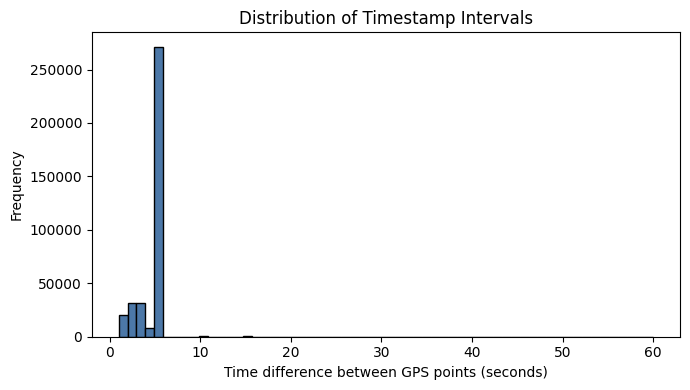

In [5]:
plt.figure(figsize=(7, 4))
plt.hist(eda_data["dt"], bins=60, color="#4C78A8", edgecolor="black")
plt.xlabel("Time difference between GPS points (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of Timestamp Intervals")
plt.tight_layout()
plt.show()


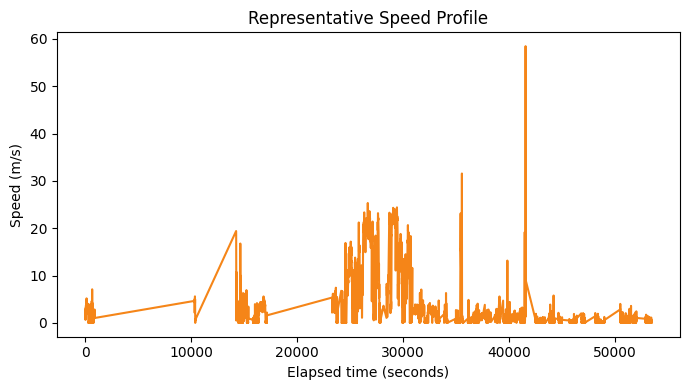

In [6]:
representative = max(processed, key=len).copy()
representative = representative[
    (representative["dt"] > 0)
    & (representative["dt"] <= 60)
    & (representative["speed_mps"] >= 0)
    & (representative["speed_mps"] <= 60)
].copy()

representative["elapsed_seconds"] = (
    representative["datetime"] - representative["datetime"].iloc[0]
).dt.total_seconds()

plt.figure(figsize=(7, 4))
plt.plot(
    representative["elapsed_seconds"],
    representative["speed_mps"],
    color="#F58518",
    linewidth=1.5
)
plt.xlabel("Elapsed time (seconds)")
plt.ylabel("Speed (m/s)")
plt.title("Representative Speed Profile")
plt.tight_layout()
plt.show()


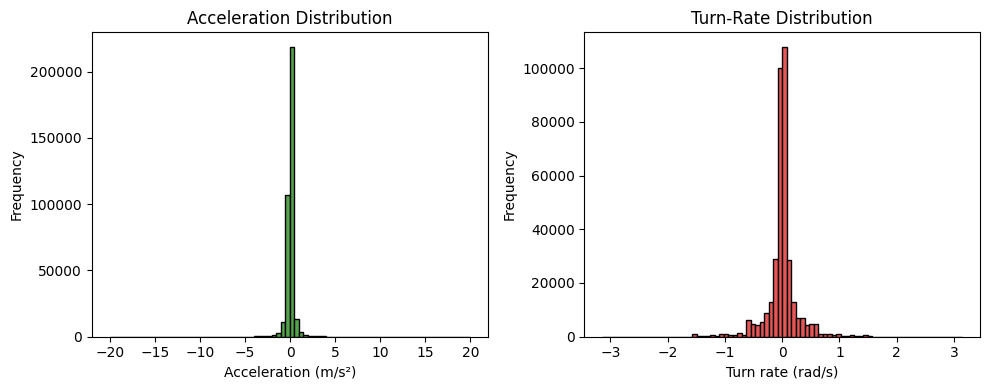

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(
    eda_data["acceleration_mps2"],
    bins=80,
    color="#54A24B",
    edgecolor="black"
)
axes[0].set_xlabel("Acceleration (m/s²)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Acceleration Distribution")

axes[1].hist(
    eda_data["turn_rate_radps"],
    bins=80,
    color="#E45756",
    edgecolor="black"
)
axes[1].set_xlabel("Turn rate (rad/s)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Turn-Rate Distribution")

plt.tight_layout()
plt.show()
